<a href="https://colab.research.google.com/github/serli2904/Tugas-Kuliah-Teknik-Pengambilan-Sampel-dan-Wrangling/blob/main/Praktikum_2_Serli_sri_lestari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library dan Membaca Dataset

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

## Membaca Dataset

- Dataset yang digunakan

In [ ]:
data = pd.read_csv('/content/1D_Porosity.csv')
data.head()

,Depth,Nporosity
0,0.25,-1.37
1,0.50,-2.08
2,0.75,-1.67
3,1.00,-1.16
4,1.25,-0.24


## Informasi Dataset

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Depth      40 non-null     float64
 1   Nporosity  40 non-null     float64
dtypes: float64(2)
memory usage: 772.0 bytes


## Statistik Deskriptif

In [ ]:
data.describe()

,Depth,Nporosity
count,40.000000,40.000000
mean,5.125000,0.022250
std,2.922613,0.992111
min,0.250000,-2.080000
25%,2.687500,-0.757500
50%,5.125000,0.140000
75%,7.562500,0.742500
max,10.000000,2.350000


## Menentukan Variabel X dan Y

- Menentukan variabel independen (X)
- Depth digunakan sebagai variabel input

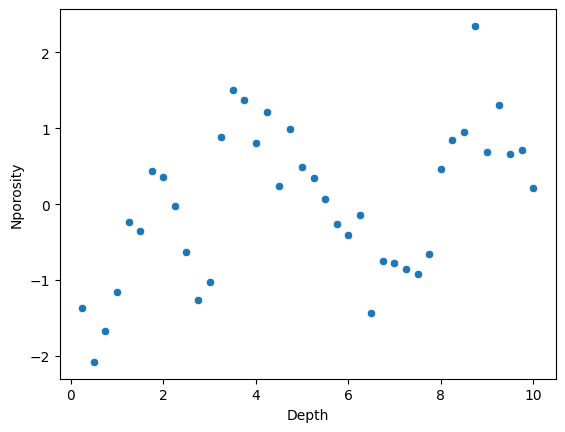

In [ ]:
sns.scatterplot(x='Depth', y='Nporosity', data=data)
plt.show()

# Regresi Linier Sederhana

Model regresi:

Y = β0 + β1X + ε

## Menentukan Variabel

In [ ]:
X = data[['Depth']]
y = data['Nporosity']

## Membuat Model Regresi sederhana

In [ ]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

## Melihat Koefisien Model

In [ ]:
print('Intercept:', model.intercept_)
print('Koefisien:', model.coef_)

Intercept: -0.6919615384615387
Koefisien: [0.13935835]


##Membuat Visualisasi Model

- Grafik ini menunjukkan hubungan antara Depth dan Nporosity
- Titik biru adalah data asli, sedangkan garis merah adalah hasil prediksi model regresi
- Garis regresi menunjukkan pola hubungan antara kedua variabel
- Jika titik data dekat dengan garis regresi, maka model cukup baik dalam memprediksi data

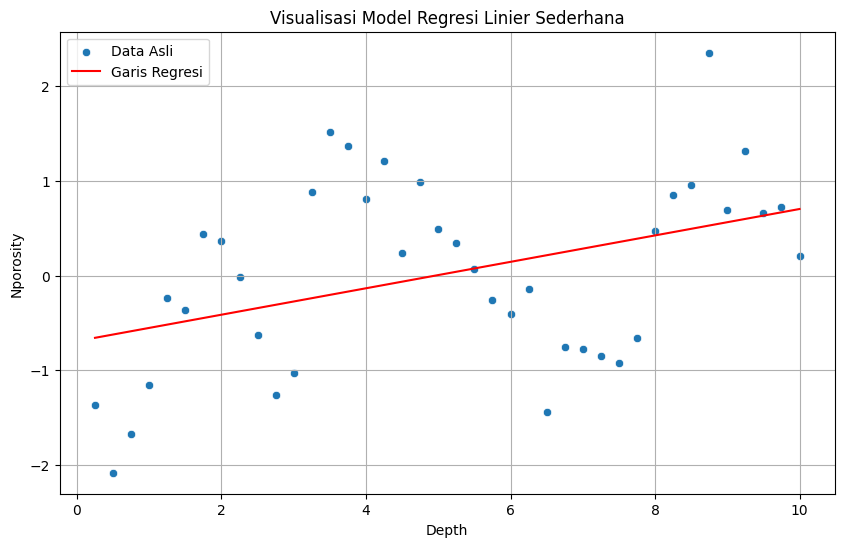

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='red', label='Garis Regresi')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('Depth')
plt.ylabel('Nporosity')
plt.legend()
plt.grid(True)
plt.show()

## PREDIKSI

- Membuat prediksi nilai Y menggunakan model regresi berdasarkan data X
- Menampilkan hasil prediksi dari model

In [ ]:
y_pred = model.predict(X)
print(y_pred)

[-0.65712195 -0.62228236 -0.58744278 -0.55260319 -0.5177636  -0.48292402
 -0.44808443 -0.41324484 -0.37840525 -0.34356567 -0.30872608 -0.27388649
 -0.2390469  -0.20420732 -0.16936773 -0.13452814 -0.09968856 -0.06484897
 -0.03000938  0.00483021  0.03966979  0.07450938  0.10934897  0.14418856
  0.17902814  0.21386773  0.24870732  0.2835469   0.31838649  0.35322608
  0.38806567  0.42290525  0.45774484  0.49258443  0.52742402  0.5622636
  0.59710319  0.63194278  0.66678236  0.70162195]


## Mean Absolute Error (MAE) , MEan Squared Error (MSE) dan Root Mean Square Error (RMSE)

In [ ]:
# Menghitung MAE (Mean Absolute Error)
mae = mean_absolute_error(y, y_pred)

# Menghitung MSE (Mean Squared Error)
mse = mean_squared_error(y, y_pred)

# Menghitung RMSE (Root Mean Squared Error)
rmse = np.sqrt(mse)

# Menampilkan hasil evaluasi model
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)

MAE : 0.7399434333958724
MSE : 0.7979390086772984
RMSE : 0.8932743188278158


## Membuat Scatter Plot Regresi

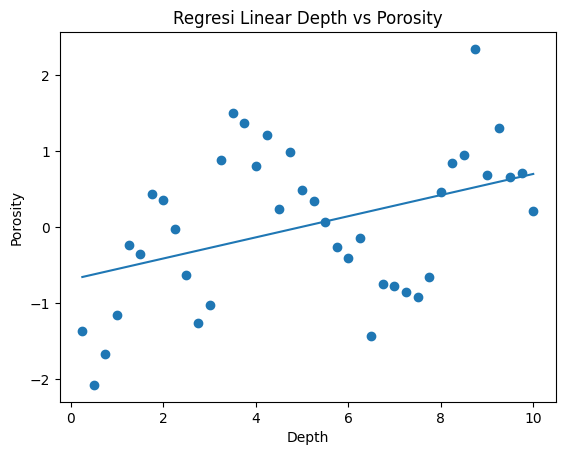

In [ ]:
plt.scatter(X, y)           # menampilkan titik data asli
plt.plot(X, y_pred)         # menampilkan garis regresi
plt.xlabel("Depth")         # label sumbu X
plt.ylabel("Porosity")      # label sumbu Y
plt.title("Regresi Linear Depth vs Porosity")  # judul grafik
plt.show()

## Regresi Polynomial Orde 2,3,4,5

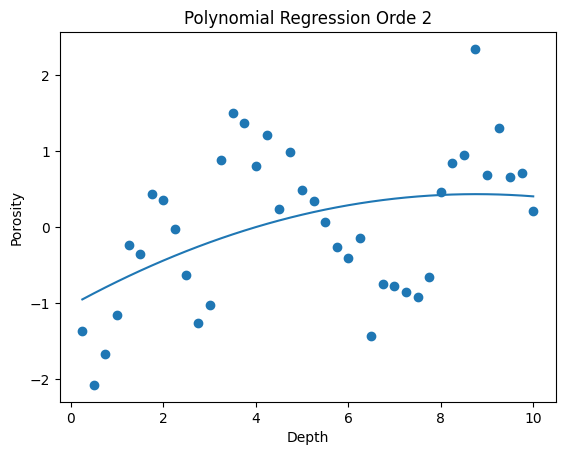

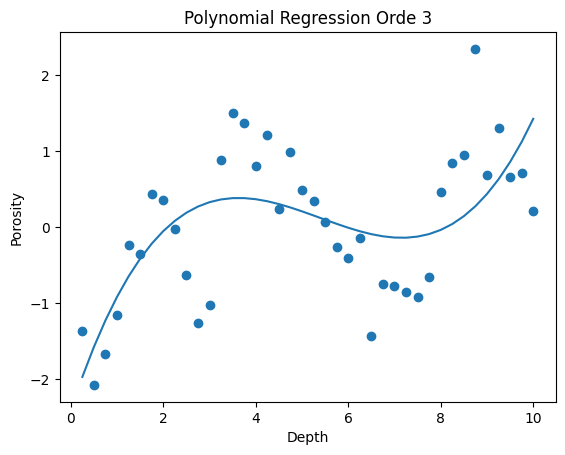

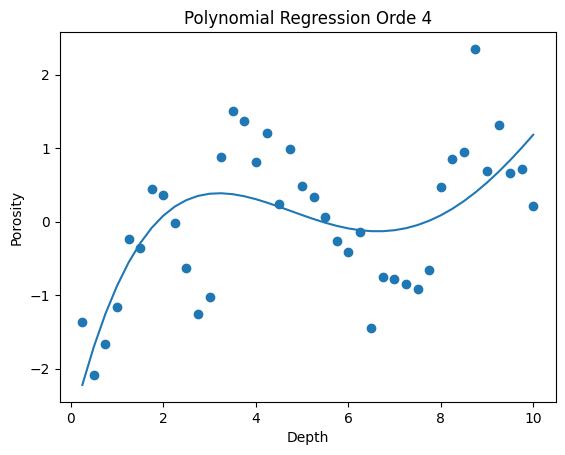

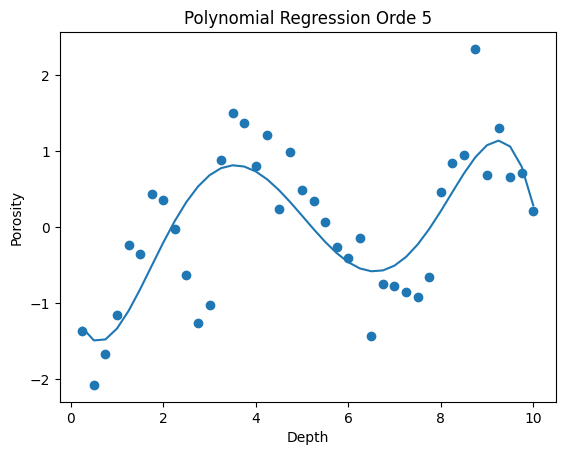

In [ ]:
for i in range(2,6):

    # Mengubah data menjadi bentuk polynomial
    poly = PolynomialFeatures(degree=i)

    X_poly = poly.fit_transform(X)

    # Membuat model regresi
    model_poly = LinearRegression()
    model_poly.fit(X_poly, y)

    # Prediksi
    y_poly_pred = model_poly.predict(X_poly)

    # Membuat grafik
    plt.scatter(X, y)
    plt.plot(X, y_poly_pred)
    plt.xlabel("Depth")
    plt.ylabel("Porosity")
    plt.title("Polynomial Regression Orde " + str(i))
    plt.show()

In [ ]:
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X)
y_pred_poly2 = model2.predict(X_poly2)
print(y_pred_poly2)

[-9.52657666e-01 -8.72351045e-01 -7.94437427e-01 -7.18916810e-01
 -6.45789195e-01 -5.75054582e-01 -5.06712970e-01 -4.40764360e-01
 -3.77208752e-01 -3.16046146e-01 -2.57276541e-01 -2.00899939e-01
 -1.46916338e-01 -9.53257381e-02 -4.61281405e-02  6.76455444e-04
  4.50880496e-02  8.71066421e-02  1.26732233e-01  1.63964822e-01
  1.98804409e-01  2.31250995e-01  2.61304578e-01  2.88965160e-01
  3.14232741e-01  3.37107319e-01  3.57588896e-01  3.75677471e-01
  3.91373044e-01  4.04675616e-01  4.15585186e-01  4.24101754e-01
  4.30225321e-01  4.33955885e-01  4.35293448e-01  4.34238009e-01
  4.30789569e-01  4.24948127e-01  4.16713683e-01  4.06086237e-01]


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

X_poly

array([[1.00000e+00, 2.50000e-01, 6.25000e-02],
       [1.00000e+00, 5.00000e-01, 2.50000e-01],
       [1.00000e+00, 7.50000e-01, 5.62500e-01],
       [1.00000e+00, 1.00000e+00, 1.00000e+00],
       [1.00000e+00, 1.25000e+00, 1.56250e+00],
       [1.00000e+00, 1.50000e+00, 2.25000e+00],
       [1.00000e+00, 1.75000e+00, 3.06250e+00],
       [1.00000e+00, 2.00000e+00, 4.00000e+00],
       [1.00000e+00, 2.25000e+00, 5.06250e+00],
       [1.00000e+00, 2.50000e+00, 6.25000e+00],
       [1.00000e+00, 2.75000e+00, 7.56250e+00],
       [1.00000e+00, 3.00000e+00, 9.00000e+00],
       [1.00000e+00, 3.25000e+00, 1.05625e+01],
       [1.00000e+00, 3.50000e+00, 1.22500e+01],
       [1.00000e+00, 3.75000e+00, 1.40625e+01],
       [1.00000e+00, 4.00000e+00, 1.60000e+01],
       [1.00000e+00, 4.25000e+00, 1.80625e+01],
       [1.00000e+00, 4.50000e+00, 2.02500e+01],
       [1.00000e+00, 4.75000e+00, 2.25625e+01],
       [1.00000e+00, 5.00000e+00, 2.50000e+01],
       [1.00000e+00, 5.25000e+00, 2.7562